## Se crea la carpeta data y se descargan los archivos

In [1]:
!mkdir -p data
!gdown 1vtJM68td0jampSL1XoXKvgmWkLeKT1Dg -O data/active_subjects.csv
!gdown 1G2Vx2NLnKQb5zAZQw5A9LwMHi5hLWYN2 -O data/audiencies.csv
!gdown 1RpZE5tq4s8JShzmxj-3ncBZfVcefEYHe -O data/institutions.csv
!gdown 1s2nKQYycgfXn8P0AybfDyoB2xx2bgS1m -O data/passive_subjects.csv

Downloading...
From (original): https://drive.google.com/uc?id=1vtJM68td0jampSL1XoXKvgmWkLeKT1Dg
From (redirected): https://drive.google.com/uc?id=1vtJM68td0jampSL1XoXKvgmWkLeKT1Dg&confirm=t&uuid=ccc69f19-8e66-49bc-b3c8-8a23ab661150
To: /Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/data/active_subjects.csv
100%|████████████████████████████████████████| 108M/108M [00:19<00:00, 5.70MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1G2Vx2NLnKQb5zAZQw5A9LwMHi5hLWYN2
From (redirected): https://drive.google.com/uc?id=1G2Vx2NLnKQb5zAZQw5A9LwMHi5hLWYN2&confirm=t&uuid=5614a30c-1dd3-4b36-a008-65d7e3abfdc8
To: /Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/data/audiencies.csv
100%|████████████████████████████████████████| 397M/397M [01:21<00:00, 4.87MB/s]
Downloading...
From: https://drive.google.com/uc?id=1RpZE5tq4s8JShzmxj-3ncBZfVcefEYHe
To: /Users/felipemarin/Documents/Chile/Ramos/Si

## Librerias importantes

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
active_subjects = pd.read_csv(os.path.join("data", "active_subjects.csv"))
audiences = pd.read_csv(os.path.join("data", 'audiencies.csv'))
institutions = pd.read_csv(os.path.join("data", 'institutions.csv'))
passive_subjects = pd.read_csv(os.path.join("data", 'passive_subjects.csv'))

Los usuarios de nuestro sistema recomendador se refieren a los sujetos pasivos y los Item hacen las veces de Sujetos Activos, en este caso se representan como los nombres

In [4]:
active_subjects.size

9230480

Nuestro dataframe cuenta con 2'741.488 audiencias entre sujetos activos y sujetos pasivos

In [5]:
audiences.head()

,institucion_id,sujeto_pasivo_id,anio,identificador,fecha,forma,lugar,duracion,audiencia_id,detalle_url,materias_tratadas,especificacion
0,AB023,634851,2024,AB023AW1527489,2024-03-18 17:00:00-03:00,Presencial,por confirmar,"2 horas, 0 minutos",691146,https://www.leylobby.gob.cl/instituciones/AB02...,"Elaboración, dictación, modificación, denegaci...",Reunión con el cuerpo colegiado del ADI y CNA ...
1,AB023,634851,2024,AB023AW1541236,2024-03-21 12:30:00-03:00,Presencial,Delegación Presidencial Provincial de Parinacota,"1 horas, 0 minutos",691322,https://www.leylobby.gob.cl/instituciones/AB02...,"Elaboración, dictación, modificación, denegaci...",Socios de JJVV de Caquena solicitan audiencia ...
2,AB023,634851,2024,AB023AW1541739,2024-03-21 13:00:00-03:00,Presencial,Delegación Presidencial Provincial de Parinacota,"0 horas, 30 minutos",691521,https://www.leylobby.gob.cl/instituciones/AB02...,"Elaboración, dictación, modificación, denegaci...",Audiencia con Delegado Presidencial Provincial...
3,AB023,634851,2024,AB023AW1544925,2024-03-25 11:00:00-03:00,Presencial,Delegación Presidencial Regional de Arica y Pa...,"1 horas, 0 minutos",692878,https://www.leylobby.gob.cl/instituciones/AB02...,"Elaboración, dictación, modificación, denegaci...",Presentación como Asociación de Ganaderos al D...
4,AB023,634851,2024,AB023AW1672741,2024-09-25 11:30:00-03:00,Presencial,Delegación Presidencial Provincial,"1 horas, 0 minutos",740813,https://www.leylobby.gob.cl/instituciones/AB02...,"Diseño, implementación y evaluación de polític...",Audiencia con el Delegado Presidencial Provinc...


In [6]:
institutions.head()

,id,name
0,AA001,Presidencia de la República
1,AB001,Subsecretaría del Interior
2,AB002,Subsecretaría de Desarrollo Regional
3,AB003,Agencia Nacional de Inteligencia
4,AB004,Servicio Nacional de Prevención y Respuesta an...


In [7]:
active_subjects

,audiencia_id,institucion_id,sujeto_pasivo_id,anio,Nombre completo,Calidad,Trabaja para,Representa a
0,691146,AB023,634851,2024,Leslie Zapata,Gestor de intereses,NaN,Leslie Alejandra Zapata Vásquez
1,691322,AB023,634851,2024,Flora Flores,Gestor de intereses,NaN,Vecinos de Caquena
2,691521,AB023,634851,2024,Clara Blanco,Gestor de intereses,NaN,Clara Blanco Mamani
3,692878,AB023,634851,2024,Conrado Blanco,Gestor de intereses,NaN,Asoc. de Ganaderos de Guallatire
4,740813,AB023,634851,2024,Yessica Sanches,Gestor de intereses,NaN,Consejo ADI
...,...,...,...,...,...,...,...,...
1153805,766862,MU284,391700,2024,JAIME OSORIO,Gestor de intereses,NaN,JAIME OSORIO
1153806,766864,MU284,391700,2024,LORENA OSORIO,Gestor de intereses,NaN,LORENA OSORIO
1153807,766866,MU284,391700,2024,LORENA OSORIO,Gestor de intereses,NaN,LORENA OSORIO
1153808,761890,MU284,712954,2024,Margarita Corrotea,Gestor de intereses,NaN,Margarita Corrotea


In [8]:
active_subjects['Nombre completo'].isna().sum()

np.int64(0)

In [9]:
passive_subjects.head()

,nombre,cargo,id,institution_id
0,Ricardo Sanzana,Delegado Presidencial Regional,456953,AB007
1,Luis Pizarro,Jefe Departamento de Coordinación Intersectorial,658160,AB007
2,Carmen Tupa,Delegado Presidencial Regional,811510,AB007
3,Cristian Riquelme,Director Administrativo,2509,AA001
4,Natalie Vilches Jara,Integrante de Comisión Evaluadora formada en e...,2524,AA001


In [10]:
conteo = active_subjects.groupby("sujeto_pasivo_id")["audiencia_id"].count().reset_index()

# renombrar columna
conteo = conteo.rename(columns={"audiencia_id": "cantidad_audiencias"})

print(conteo)

       sujeto_pasivo_id  cantidad_audiencias
0                    15                   42
1                    33                  165
2                    40                    2
3                    41                   15
4                    43                  244
...                 ...                  ...
20476            763937                    2
20477            765003                    7
20478            769978                    1
20479            782023                    2
20480            783338                    1

[20481 rows x 2 columns]


Contamos con 9875 sujetos pasivos distintos

In [11]:
conteo_nombres = active_subjects.groupby("Nombre completo")["audiencia_id"].count().reset_index()
conteo_nombres = conteo_nombres.rename(columns={"audiencia_id": "cantidad_audiencias"})
conteo_nombres = conteo_nombres.sort_values(
    by="cantidad_audiencias", ascending=False
).reset_index(drop=True)

In [11]:
conteo_nombres

,Nombre completo,cantidad_audiencias
0,Carlos Alberto Vargas Godoy,323
1,Marcelo Campos Larraín,208
2,Luis Figueroa,207
3,Jorge Cortés,200
4,Felipe Palacio,183
...,...,...
120783,JUAN LEON,1
120784,JUAN LEODAN GARRIDO,1
120785,JUAN JOSE TARIFA SALLES,1
120786,JUAN JOSE QUEVEDO CACERES,1


Y un total de 120.788 Sujetos Activos distintos

## Manejo de datos

In [12]:
df = active_subjects[["sujeto_pasivo_id", "Nombre completo"]].copy()


In [13]:
import numpy as np
from sklearn.metrics import accuracy_score

df = active_subjects[["sujeto_pasivo_id", "Nombre completo"]].copy()

# espacio de etiquetas
nombres_unicos = df["Nombre completo"].unique()

# función para predecir aleatoriamente
def random_predict(df, nombres_unicos, seed=None):
    if seed is not None:
        np.random.seed(seed)
    return np.random.choice(nombres_unicos, size=len(df))

# generar predicciones
y_true = df["Nombre completo"].values
y_pred = random_predict(df, nombres_unicos, seed=42)

# medir precisión
precision = accuracy_score(y_true, y_pred)

print("Precisión del modelo aleatorio:", precision)


Precisión del modelo aleatorio: 5.2001629384387375e-06


In [14]:
from sklearn.metrics import accuracy_score

def most_popular_recommender(df):
    # encontrar el nombre más frecuente en todo el dataset
    most_popular = df["Nombre completo"].value_counts().idxmax()
    # predecir siempre ese nombre
    y_pred = [most_popular] * len(df)
    return y_pred

# uso
y_true = df["Nombre completo"].values
y_pred = most_popular_recommender(df)

precision = accuracy_score(y_true, y_pred)
print("Precisión del modelo Most Popular:", precision)


Precisión del modelo Most Popular: 0.0005364834764822631


In [15]:
from sklearn.metrics import accuracy_score

def most_popular_by_id(df):
    # calcular el nombre más frecuente para cada sujeto_pasivo_id
    popular_map = (
        df.groupby("sujeto_pasivo_id")["Nombre completo"]
        .agg(lambda x: x.value_counts().idxmax())
        .to_dict()
    )

    # predecir según el sujeto_pasivo_id de cada fila
    y_pred = df["sujeto_pasivo_id"].map(popular_map).values
    return y_pred

# uso
y_true = df["Nombre completo"].values
y_pred = most_popular_by_id(df)

precision = accuracy_score(y_true, y_pred)
print("Precisión del modelo Most Popular por ID:", precision)


Precisión del modelo Most Popular por ID: 0.04629358386562779


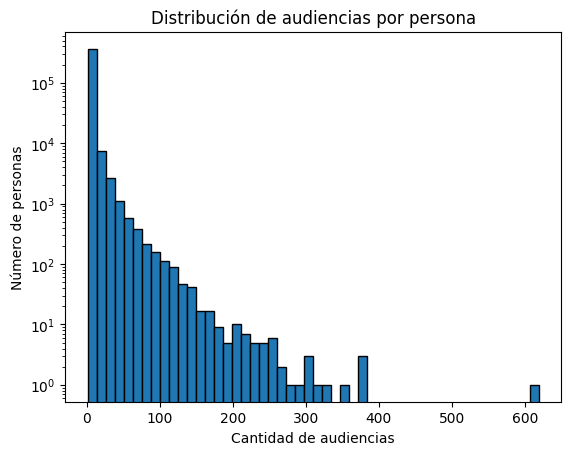

In [16]:
import matplotlib.pyplot as plt

# contar audiencias por nombre
conteo = df["Nombre completo"].value_counts()

# histograma de las cantidades
plt.hist(conteo.values, bins=50, edgecolor="black", log = True)
plt.xlabel("Cantidad de audiencias")
plt.ylabel("Número de personas")
plt.title("Distribución de audiencias por persona")
plt.show()


In [17]:
conteo

Nombre completo
Carlos Alberto Vargas Godoy    619
Luis Del Solar                 375
José Correa                    372
Sebastián Avilés               372
Gonzalo Cubillos               358
                              ... 
Víctor Díaz Iturriaga            1
Emilio Cifuentes                 1
Violaine DE NEEF                 1
pedro terrado                    1
NATALY CASTILLO ZEPEDA           1
Name: count, Length: 376788, dtype: int64